# Brute Force Algorithms Experimental Analysis

This notebook contains experimental tests and visualizations for the three brute force algorithms:
1. Pure Brute Force
2. Brute Force with Pruning
3. Hybrid (Brute Force + Dynamic Programming)

All tests are designed to generate data and figures for inclusion in the LaTeX report.


In [37]:
# Cell 1: Imports and Setup
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os
from pathlib import Path
import sys
import importlib.util

# Add current directory to path to import algorithms
sys.path.insert(0, str(Path.cwd()))

from pure_brute_force import pure_brute_force, is_valid_tour
from pruning_brute_force import brute_force_with_pruning
from instance_generator import generate_unified_test_instance
from BF_DP_hybrid import hybrid_brute_force_dp

# Force reload modules to ensure we have latest versions with timeout support
import importlib
import pure_brute_force
import pruning_brute_force
import BF_DP_hybrid
importlib.reload(pure_brute_force)
importlib.reload(pruning_brute_force)
importlib.reload(BF_DP_hybrid)

# Re-import after reload
from pure_brute_force import pure_brute_force, is_valid_tour
from pruning_brute_force import brute_force_with_pruning
from BF_DP_hybrid import hybrid_brute_force_dp

# Verify functions have timeout parameter
import inspect
if 'timeout' not in inspect.signature(pure_brute_force).parameters:
    raise RuntimeError("pure_brute_force does not have timeout parameter - check imports")
if 'timeout' not in inspect.signature(brute_force_with_pruning).parameters:
    raise RuntimeError("brute_force_with_pruning does not have timeout parameter - check imports")
if 'timeout' not in inspect.signature(hybrid_brute_force_dp).parameters:
    raise RuntimeError("hybrid_brute_force_dp does not have timeout parameter - check imports")

# Set random seed for reproducibility
import random
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Configure matplotlib for publication-quality figures
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Create output directories for figures and data
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Setup complete. Ready to run experiments.")


Setup complete. Ready to run experiments.


## Cell 2: Execution Time Growth Analysis

Tests all three algorithms for increasing instance sizes (n = 3 to 8) and measures execution time to demonstrate exponential growth.


In [4]:
# Cell 2: Execution Time Growth Analysis
def run_growth_analysis(timeout=200.0):
    """Run all three algorithms for increasing instance sizes and measure execution time."""
    
    sizes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    results = {
        'n': [],
        'pure_bf_time': [],
        'pruned_bf_time': [],
        'hybrid_time': [],
        'pure_bf_capital': [],
        'pruned_bf_capital': [],
        'hybrid_capital': []
    }
    
    print("="*80)
    print("EXECUTION TIME GROWTH ANALYSIS")
    print("="*80)
    print(f"\n{'n':>3} | {'Pure BF (s)':>15} | {'Pruned BF (s)':>15} | {'Hybrid (s)':>15} | {'Status':>20}")
    print("-"*80)
    
    for n in sizes:
        print(f"{n:3} | ", end="", flush=True)
        
        # Generate instance
        instance = generate_unified_test_instance(n_ports=n, seed=RANDOM_SEED)
        
        # Test Pure Brute Force (only for small instances)
        if n < 10:
            try:
                start = time.time()
                result_pure = pure_brute_force(instance, timeout=timeout)
                time_pure = time.time() - start
                timeout_pure = result_pure.get('timeout', False)
                capital_pure = result_pure.get('final_capital', None)
                results['pure_bf_time'].append(time_pure)
                results['pure_bf_capital'].append(capital_pure)
                if timeout_pure:
                    print(f"{'TIMEOUT':>15} | ", end="", flush=True)
                else:
                    print(f"{time_pure:>15.4f} | ", end="", flush=True)
            except Exception as e:
                results['pure_bf_time'].append(float('inf'))
                results['pure_bf_capital'].append(None)
                print(f"{'N/A (error)':>15} | ", end="", flush=True)
                if n <= 4:
                    print(f"Error in Pure BF for n={n}: {type(e).__name__}: {e}", flush=True)
        else:
            results['pure_bf_time'].append(float('inf'))
            results['pure_bf_capital'].append(None)
            print(f"{'N/A (too large)':>15} | ", end="", flush=True)
        
        # Test Pruned Brute Force
        if n <= 10:
            try:
                start = time.time()
                result_pruned = brute_force_with_pruning(instance, timeout=timeout)
                time_pruned = time.time() - start
                timeout_pruned = result_pruned.get('timeout', False)
                capital_pruned = result_pruned.get('final_capital', None)
                results['pruned_bf_time'].append(time_pruned)
                results['pruned_bf_capital'].append(capital_pruned)
                if timeout_pruned:
                    print(f"{'TIMEOUT':>15} | ", end="", flush=True)
                else:
                    print(f"{time_pruned:>15.4f} | ", end="", flush=True)
            except Exception as e:
                results['pruned_bf_time'].append(float('inf'))
                results['pruned_bf_capital'].append(None)
                print(f"{'N/A (error)':>15} | ", end="", flush=True)
                if n <= 4:
                    print(f"Error in Pruned BF for n={n}: {type(e).__name__}: {e}", flush=True)
        else:
            results['pruned_bf_time'].append(float('inf'))
            results['pruned_bf_capital'].append(None)
            print(f"{'N/A (too large)':>15} | ", end="", flush=True)

        # Test Hybrid
        try:
            start = time.time()
            result_hybrid = hybrid_brute_force_dp(instance, timeout=timeout)
            time_hybrid = time.time() - start
            timeout_hybrid = result_hybrid.get('timeout', False)
            capital_hybrid = result_hybrid.get('final_capital', None)
            results['hybrid_time'].append(time_hybrid)
            results['hybrid_capital'].append(capital_hybrid)
            if timeout_hybrid:
                print(f"{'TIMEOUT':>15} | ", end="", flush=True)
            else:
                print(f"{time_hybrid:>15.4f} | ", end="", flush=True)
        except Exception as e:
            results['hybrid_time'].append(float('inf'))
            results['hybrid_capital'].append(None)
            print(f"{'N/A (error)':>15} | ", end="", flush=True)
            if n <= 4:
                print(f"Error in Hybrid for n={n}: {type(e).__name__}: {e}", flush=True)
        
        # Status
        status = []
        if results['pure_bf_time'][-1] != float('inf') and not result_pure.get('timeout', False):
            status.append("Pure✓")
        if results['pruned_bf_time'][-1] != float('inf') and not result_pruned.get('timeout', False):
            status.append("Pruned✓")
        if results['hybrid_time'][-1] != float('inf') and not result_hybrid.get('timeout', False):
            status.append("Hybrid✓")
        print(f"{', '.join(status):>20}")
        
        results['n'].append(n)
    
    return results

# Run the analysis
growth_results = run_growth_analysis(timeout=200.0)

# Save to CSV
df_growth = pd.DataFrame(growth_results)
df_growth.to_csv('data/growth_analysis.csv', index=False)
print("\n✓ Growth analysis data saved to data/growth_analysis.csv")


EXECUTION TIME GROWTH ANALYSIS

  n |     Pure BF (s) |   Pruned BF (s) |      Hybrid (s) |               Status
--------------------------------------------------------------------------------
  3 |          0.0003 |          0.0001 |          0.0003 | Pure✓, Pruned✓, Hybrid✓
  4 |          0.0004 |          0.0004 |          0.0004 | Pure✓, Pruned✓, Hybrid✓
  5 |          0.0067 |          0.0021 |          0.0017 | Pure✓, Pruned✓, Hybrid✓
  6 | 

         0.1018 |          0.0308 |          0.0312 | Pure✓, Pruned✓, Hybrid✓
  7 |          1.0368 |          0.2730 |          0.1856 | Pure✓, Pruned✓, Hybrid✓
  8 |         21.2869 |          5.0484 |          0.3884 | Pure✓, Pruned✓, Hybrid✓
  9 |         TIMEOUT |         90.7548 |          9.7152 |     Pruned✓, Hybrid✓
 10 | N/A (too large) |         TIMEOUT |          5.1573 |              Hybrid✓
 11 | N/A (too large) | N/A (too large) |         31.9570 |              Hybrid✓
 12 | N/A (too large) | N/A (too large) |        200.0000 |              Hybrid✓

✓ Growth analysis data saved to data/growth_analysis.csv


✓ Figure 1 saved: figures/growth_curves.png and .pdf


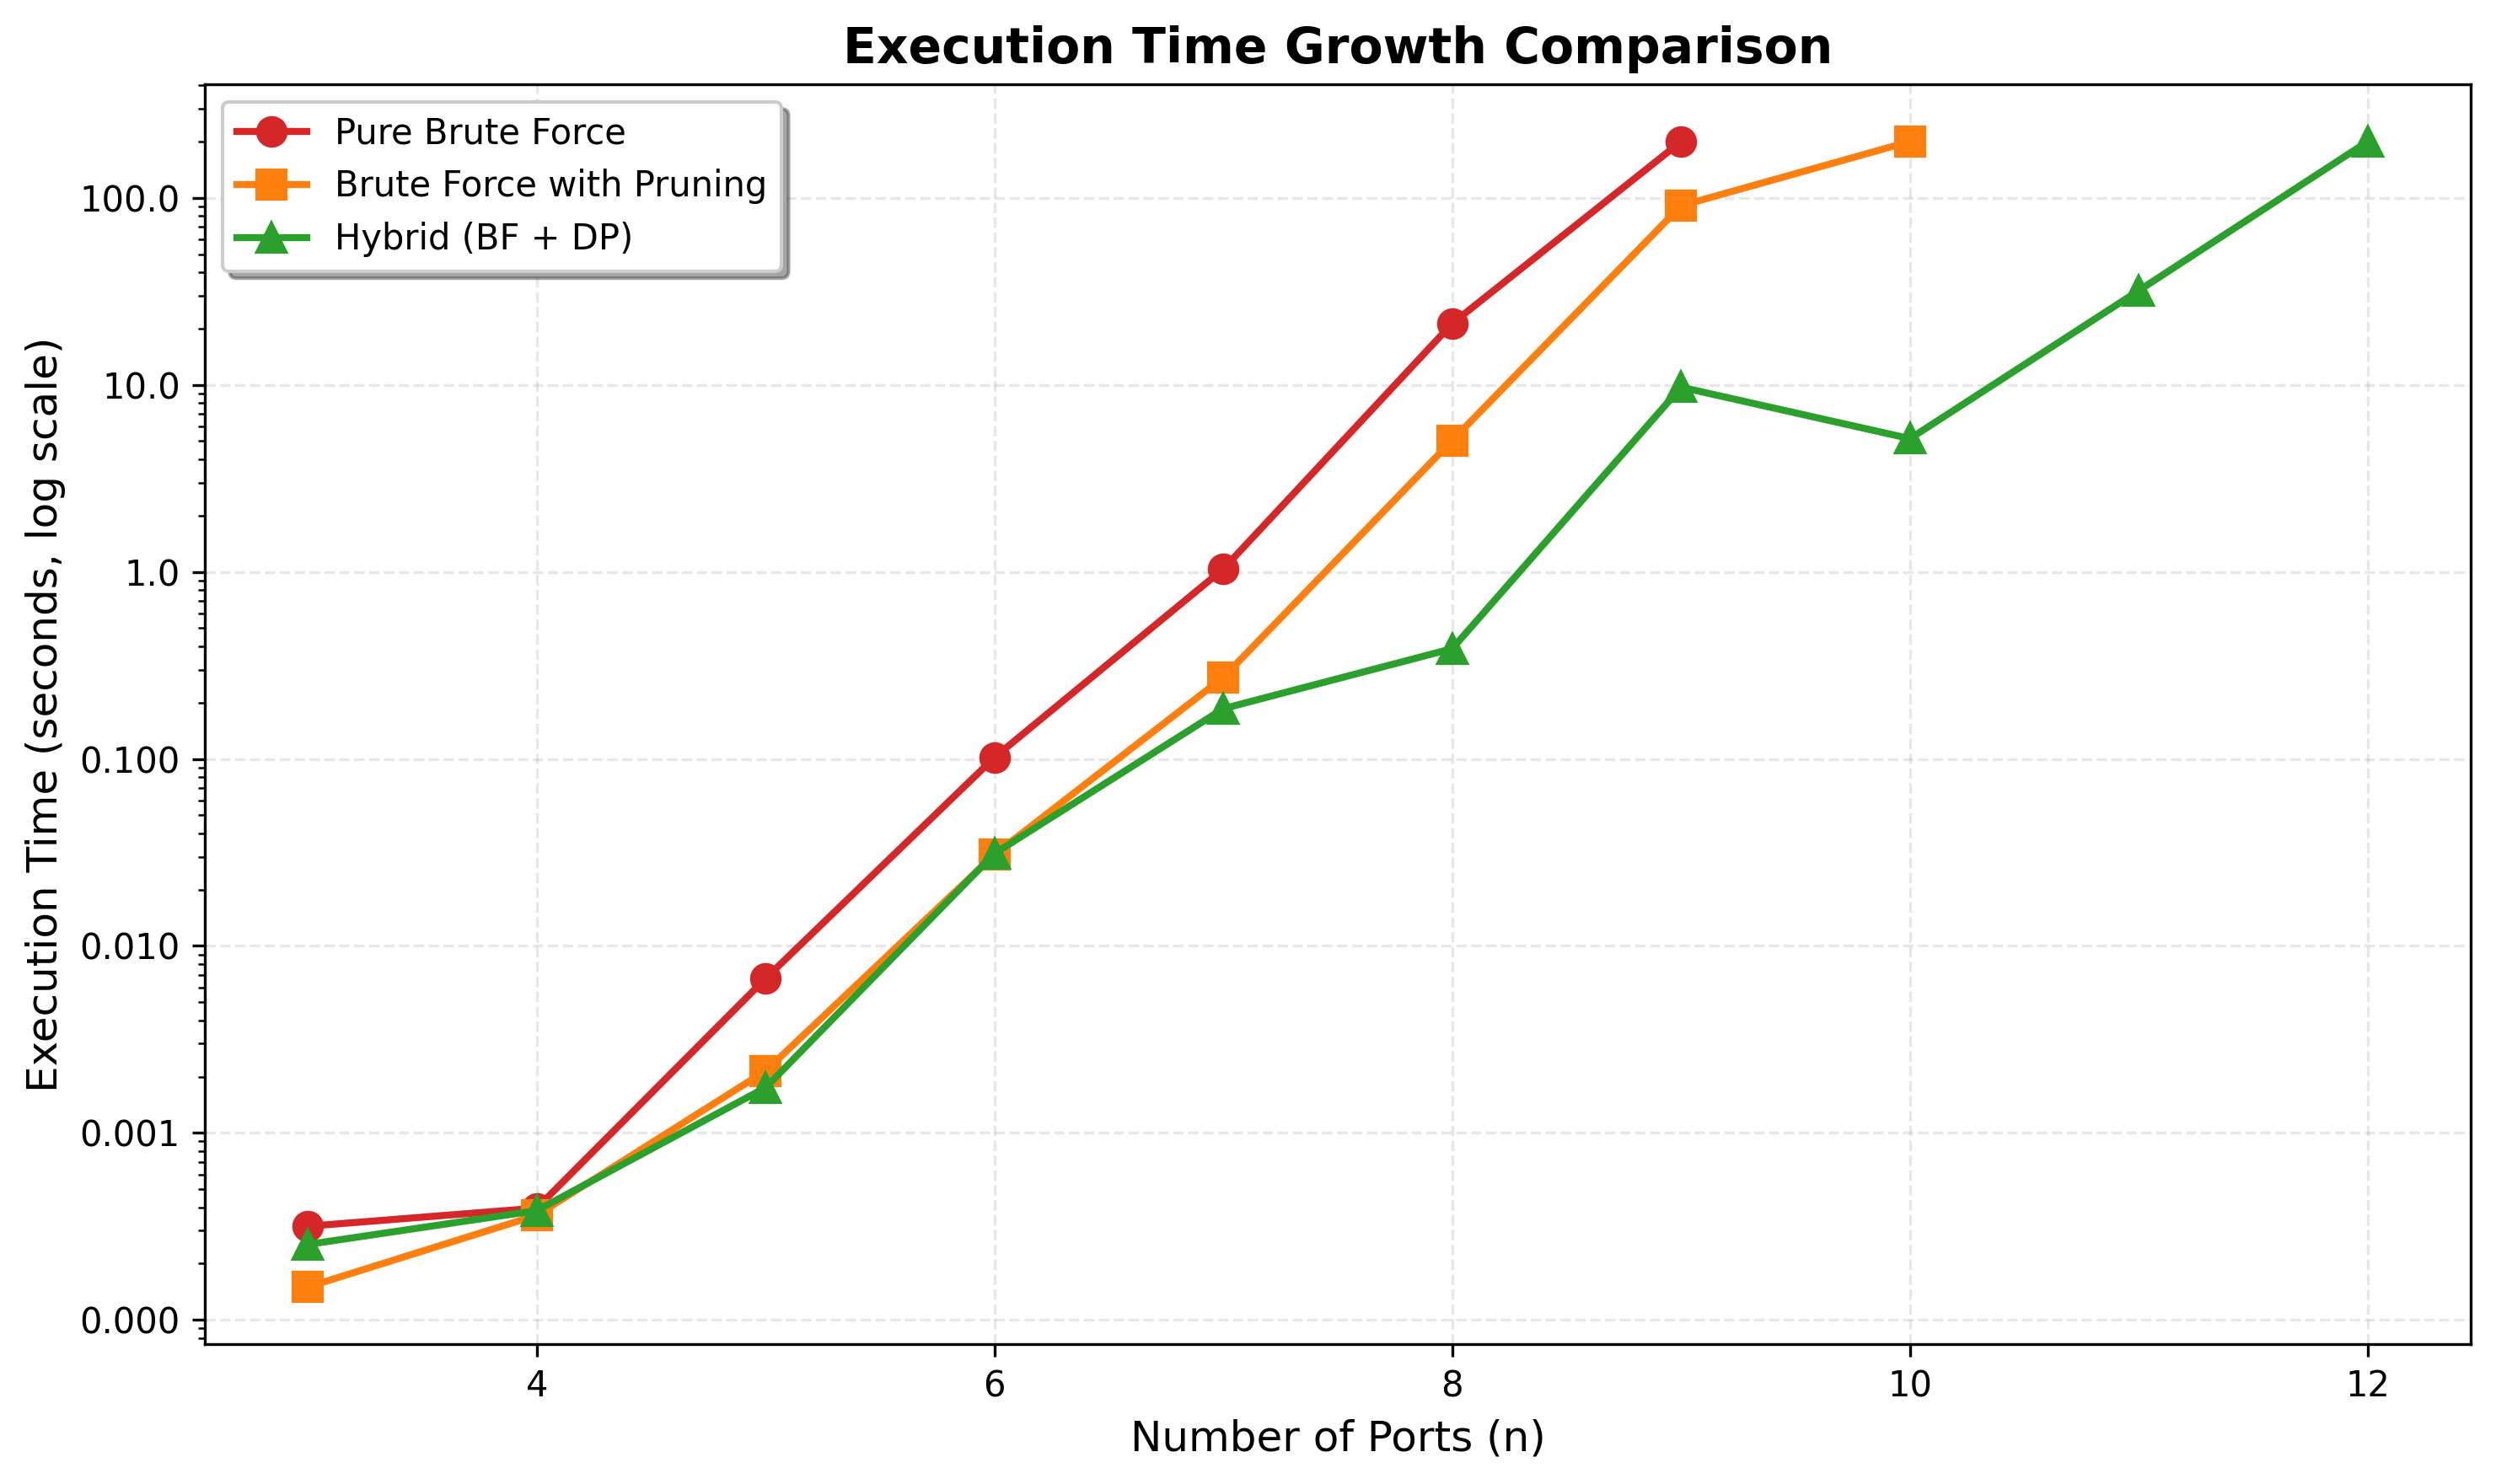

In [8]:
# Generate Figure 1: Growth Curves (Log Scale)
def plot_growth_curves(results):
    """Generate log-scale plot showing exponential growth."""
    
    n_values = results['n']
    pure_times = [t if t != float('inf') else None for t in results['pure_bf_time']]
    pruned_times = [t if t != float('inf') else None for t in results['pruned_bf_time']]
    hybrid_times = [t if t != float('inf') else None for t in results['hybrid_time']]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot lines
    pure_line = ax.plot(n_values, pure_times, 'o-', label='Pure Brute Force', 
                        linewidth=2, markersize=8, color='#d62728')
    pruned_line = ax.plot(n_values, pruned_times, 's-', label='Brute Force with Pruning', 
                          linewidth=2, markersize=8, color='#ff7f0e')
    hybrid_line = ax.plot(n_values, hybrid_times, '^-', label='Hybrid (BF + DP)', 
                          linewidth=2, markersize=8, color='#2ca02c')
    
    # Set log scale
    ax.set_yscale('log')
    
    # Labels and title
    ax.set_xlabel('Number of Ports (n)', fontsize=12)
    ax.set_ylabel('Execution Time (seconds, log scale)', fontsize=12)
    ax.set_title('Execution Time Growth Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Format y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}' if x < 1 else f'{x:.1f}'))
    
    plt.tight_layout()
    
    # Save in multiple formats
    plt.savefig('figures/growth_curves.png', dpi=300, bbox_inches='tight')
    plt.savefig('figures/growth_curves.pdf', bbox_inches='tight')
    print("✓ Figure 1 saved: figures/growth_curves.png and .pdf")
    
    plt.show()

plot_growth_curves(growth_results)


## Cell 3: Direct Comparison Test

Runs all three algorithms on the same instances (n = 4, 5, 6) to compare execution times, solutions found, and search space explored. Verifies that all algorithms find the same optimal solution.


In [26]:
# Cell 3: Direct Comparison Test
def run_comparison_test():
    """Run all three algorithms on same instances and compare results."""
    
    comparison_sizes = [4, 5, 6]
    comparison_results = []
    
    print("="*80)
    print("DIRECT COMPARISON TEST")
    print("="*80)
    
    for n in comparison_sizes:
        print(f"\n{'='*60}")
        print(f"Testing with n = {n} ports")
        print(f"{'='*60}")
        
        # Generate instance (use same seed for reproducibility)
        instance = generate_unified_test_instance(n_ports=n, seed=RANDOM_SEED)
        
        result_entry = {'n': n}
        
        # Test Pure Brute Force
        if n < 10:
            print("\n1. Pure Brute Force:")
            try:
                start = time.time()
                result_pure = pure_brute_force(instance, timeout=200.0)
                time_pure = time.time() - start
                
                result_entry['pure_time'] = time_pure
                result_entry['pure_capital'] = result_pure.get('final_capital')
                result_entry['pure_solutions'] = result_pure.get('explored_solutions', 'N/A')
                
                print(f"   Time: {time_pure:.4f}s")
                print(f"   Final Capital: {result_entry['pure_capital']:.2f}" if result_entry['pure_capital'] else "   No solution found")
                print(f"   Solutions Explored: {result_entry['pure_solutions']}")
            except Exception as e:
                result_entry['pure_time'] = float('inf')
                result_entry['pure_capital'] = None
                result_entry['pure_solutions'] = 'N/A'
                print(f"   Failed: {e}")
        else:
            result_entry['pure_time'] = float('inf')
            result_entry['pure_capital'] = None
            result_entry['pure_solutions'] = 'N/A'
            print("\n1. Pure Brute Force: Skipped (too large)")
        
        # Test Pruned Brute Force
        print("\n2. Brute Force with Pruning:")
        try:
            start = time.time()
            result_pruned = brute_force_with_pruning(instance, timeout=200.0)
            time_pruned = time.time() - start
            
            stats = result_pruned.get('pruning_statistics', {})
            result_entry['pruned_time'] = time_pruned
            result_entry['pruned_capital'] = result_pruned.get('final_capital')
            result_entry['pruned_nodes'] = stats.get('recursive_calls', 'N/A')
            result_entry['pruned_pruned'] = stats.get('branches_pruned', 'N/A')
            
            print(f"   Time: {time_pruned:.4f}s")
            print(f"   Final Capital: {result_entry['pruned_capital']:.2f}" if result_entry['pruned_capital'] else "   No solution found")
            print(f"   Nodes Explored: {result_entry['pruned_nodes']}")
            print(f"   Branches Pruned: {result_entry['pruned_pruned']}")
        except Exception as e:
            result_entry['pruned_time'] = float('inf')
            result_entry['pruned_capital'] = None
            result_entry['pruned_nodes'] = 'N/A'
            result_entry['pruned_pruned'] = 'N/A'
            print(f"   Failed: {e}")
        
        # Test Hybrid
        print("\n3. Hybrid (BF + DP):")
        try:
            start = time.time()
            result_hybrid = hybrid_brute_force_dp(instance, timeout=200.0)
            time_hybrid = time.time() - start
            
            stats = result_hybrid.get('statistics', {})
            result_entry['hybrid_time'] = time_hybrid
            result_entry['hybrid_capital'] = result_hybrid.get('final_capital')
            result_entry['hybrid_routes'] = stats.get('routes_explored', 'N/A')
            result_entry['hybrid_dp_execs'] = stats.get('dp_executions', 'N/A')
            
            print(f"   Time: {time_hybrid:.4f}s")
            print(f"   Final Capital: {result_entry['hybrid_capital']:.2f}" if result_entry['hybrid_capital'] else "   No solution found")
            print(f"   Routes Explored: {result_entry['hybrid_routes']}")
            print(f"   DP Executions: {result_entry['hybrid_dp_execs']}")
        except Exception as e:
            result_entry['hybrid_time'] = float('inf')
            result_entry['hybrid_capital'] = None
            result_entry['hybrid_routes'] = 'N/A'
            result_entry['hybrid_dp_execs'] = 'N/A'
            print(f"   Failed: {e}")
        
        # Verify solution quality (all should find same optimal capital)
        print("\n4. Solution Quality Verification:")
        capitals = [result_entry['pure_capital'], result_entry['pruned_capital'], result_entry['hybrid_capital']]
        valid_capitals = [c for c in capitals if c is not None and c != float('inf')]
        
        if len(valid_capitals) > 1:
            if all(abs(c - valid_capitals[0]) < 0.01 for c in valid_capitals):
                print(f"   ✓ All algorithms found the same optimal capital: {valid_capitals[0]:.2f}")
                result_entry['quality_match'] = True
            else:
                print(f"   ⚠ WARNING: Capital mismatch!")
                print(f"   Pure: {result_entry['pure_capital']}")
                print(f"   Pruned: {result_entry['pruned_capital']}")
                print(f"   Hybrid: {result_entry['hybrid_capital']}")
                result_entry['quality_match'] = False
        else:
            print(f"   Cannot verify (not all algorithms completed)")
            result_entry['quality_match'] = None
        
        comparison_results.append(result_entry)
    
    return comparison_results

comparison_results = run_comparison_test()

# Save to CSV
df_comparison = pd.DataFrame(comparison_results)
df_comparison.to_csv('data/comparison_test.csv', index=False)
print("\n✓ Comparison test data saved to data/comparison_test.csv")


DIRECT COMPARISON TEST

Testing with n = 4 ports

1. Pure Brute Force:
   Time: 0.0011s
   Final Capital: 89.00
   Solutions Explored: 226

2. Brute Force with Pruning:
   Time: 0.0008s
   Final Capital: 89.00
   Nodes Explored: N/A
   Branches Pruned: 39

3. Hybrid (BF + DP):
   Time: 0.0008s
   Final Capital: 89.00
   Routes Explored: 16
   DP Executions: 6

4. Solution Quality Verification:
   ✓ All algorithms found the same optimal capital: 89.00

Testing with n = 5 ports

1. Pure Brute Force:
   Time: 0.0113s
   Final Capital: 116.00
   Solutions Explored: 2713

2. Brute Force with Pruning:
   Time: 0.0044s
   Final Capital: 116.00
   Nodes Explored: N/A
   Branches Pruned: 372

3. Hybrid (BF + DP):
   Time: 0.0035s
   Final Capital: 116.00
   Routes Explored: 65
   DP Executions: 48

4. Solution Quality Verification:
   ✓ All algorithms found the same optimal capital: 116.00

Testing with n = 6 ports

1. Pure Brute Force:
   Time: 0.1016s
   Final Capital: 139.00
   Solutions Exp

✓ Figure 2 saved: figures/comparison_bar_chart.png and .pdf


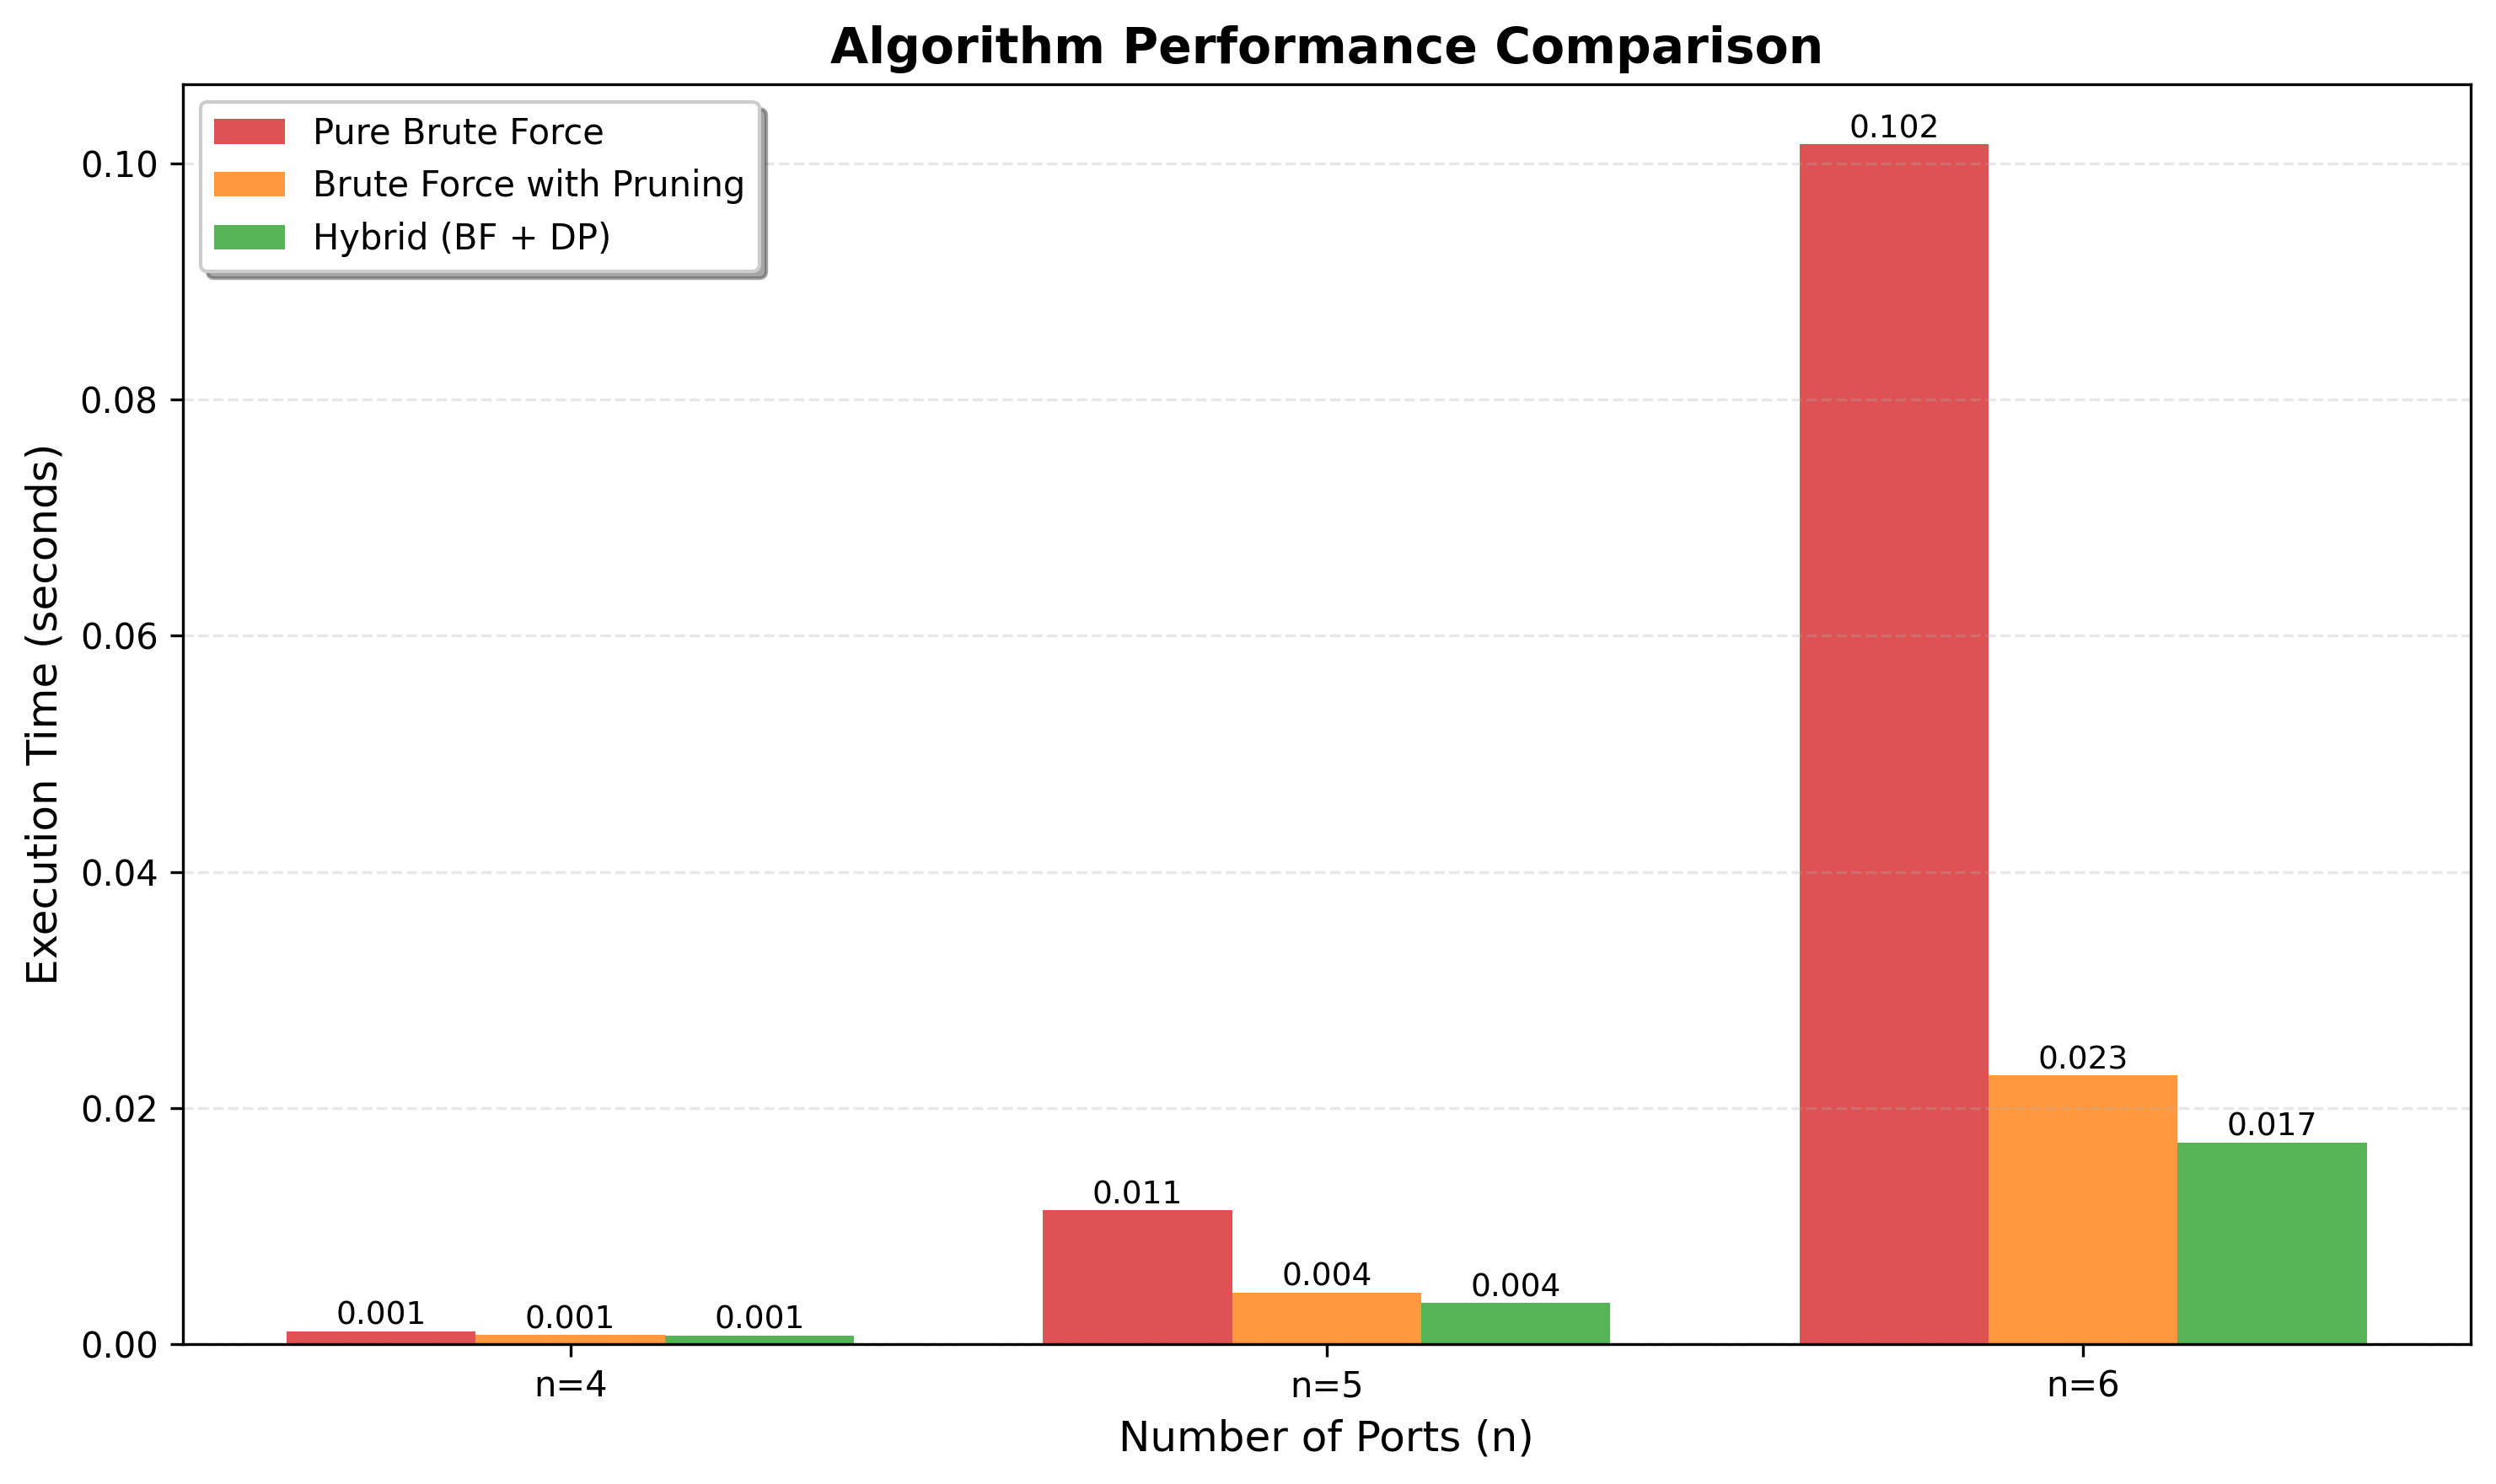

In [27]:
# Generate Figure 2: Bar Chart Comparison
def plot_comparison_bar_chart(results):
    """Generate bar chart comparing execution times."""
    
    n_values = [r['n'] for r in results]
    # Replace None and inf with 0 for visualization (matplotlib can't handle None)
    pure_times = [r.get('pure_time', 0) if r.get('pure_time') != float('inf') and r.get('pure_time') is not None else 0 for r in results]
    pruned_times = [r.get('pruned_time', 0) if r.get('pruned_time') != float('inf') and r.get('pruned_time') is not None else 0 for r in results]
    hybrid_times = [r.get('hybrid_time', 0) if r.get('hybrid_time') != float('inf') and r.get('hybrid_time') is not None else 0 for r in results]
    
    x = np.arange(len(n_values))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bars
    bars1 = ax.bar(x - width, pure_times, width, label='Pure Brute Force', color='#d62728', alpha=0.8)
    bars2 = ax.bar(x, pruned_times, width, label='Brute Force with Pruning', color='#ff7f0e', alpha=0.8)
    bars3 = ax.bar(x + width, hybrid_times, width, label='Hybrid (BF + DP)', color='#2ca02c', alpha=0.8)
    
    # Labels
    ax.set_xlabel('Number of Ports (n)', fontsize=12)
    ax.set_ylabel('Execution Time (seconds)', fontsize=12)
    ax.set_title('Algorithm Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in n_values])
    ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Add value labels on bars (skip bars with 0 height, which represent missing data)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height is not None and not np.isnan(height) and height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Save
    plt.savefig('figures/comparison_bar_chart.png', dpi=300, bbox_inches='tight')
    plt.savefig('figures/comparison_bar_chart.pdf', bbox_inches='tight')
    print("✓ Figure 2 saved: figures/comparison_bar_chart.png and .pdf")
    
    plt.show()

plot_comparison_bar_chart(comparison_results)


## Cell 4: Pruning Effectiveness Analysis

Analyzes the effectiveness of different pruning techniques in the brute force with pruning algorithm.


In [28]:
# Cell 4: Pruning Effectiveness Analysis
def run_pruning_analysis():
    """Analyze pruning effectiveness for different instance sizes."""
    
    pruning_sizes = [5, 7, 9, 11]
    pruning_data = []
    
    print("="*80)
    print("PRUNING EFFECTIVENESS ANALYSIS")
    print("="*80)
    print(f"\n{'n':>3} | {'Total Calls':>12} | {'Pruned':>12} | {'Pruning Rate':>15} | {'Breakdown':>40}")
    print("-"*80)
    
    for n in pruning_sizes:
        # Generate instance
        instance = generate_unified_test_instance(n_ports=n, seed=RANDOM_SEED)
        
        try:
            start = time.time()
            result = brute_force_with_pruning(instance, timeout=200.0)
            elapsed = time.time() - start
            
            stats = result.get('pruning_statistics', {})
            total_calls = stats.get('branches_explored', 0)  # Fixed: use 'branches_explored' not 'recursive_calls'
            total_pruned = stats.get('branches_pruned', 0)
            pruning_rate = (total_pruned / total_calls * 100) if total_calls > 0 else 0
            
            breakdown = stats.get('pruning_breakdown', {})
            
            entry = {
                'n': n,
                'total_calls': total_calls,
                'total_pruned': total_pruned,
                'pruning_rate': pruning_rate,
                'pruned_by_time': stats.get('pruned_by_time', 0),
                'pruned_by_bound': stats.get('pruned_by_bound', 0),
                'pruned_by_capacity': stats.get('pruned_by_capacity', 0),
                'pruned_by_capital': stats.get('pruned_by_capital', 0),
                'execution_time': elapsed
            }
            
            # Calculate percentages
            if total_pruned > 0:
                entry['pct_time'] = (entry['pruned_by_time'] / total_pruned) * 100
                entry['pct_bound'] = (entry['pruned_by_bound'] / total_pruned) * 100
                entry['pct_capacity'] = (entry['pruned_by_capacity'] / total_pruned) * 100
                entry['pct_capital'] = (entry['pruned_by_capital'] / total_pruned) * 100
            else:
                entry['pct_time'] = 0
                entry['pct_bound'] = 0
                entry['pct_capacity'] = 0
                entry['pct_capital'] = 0
            
            pruning_data.append(entry)
            
            # Print summary
            breakdown_str = f"Time:{entry['pct_time']:.1f}%, Bound:{entry['pct_bound']:.1f}%, Cap:{entry['pct_capacity']:.1f}%, Capital:{entry['pct_capital']:.1f}%"
            print(f"{n:3} | {total_calls:12,} | {total_pruned:12,} | {pruning_rate:14.1f}% | {breakdown_str}")
            
        except Exception as e:
            print(f"{n:3} | Failed: {e}")
            continue
    
    return pruning_data

pruning_data = run_pruning_analysis()

# Save to CSV
if pruning_data:
    df_pruning = pd.DataFrame(pruning_data)
    df_pruning.to_csv('data/pruning_analysis.csv', index=False)
    print("\n✓ Pruning analysis data saved to data/pruning_analysis.csv")


PRUNING EFFECTIVENESS ANALYSIS

  n |  Total Calls |       Pruned |    Pruning Rate |                                Breakdown
--------------------------------------------------------------------------------
  5 |        1,821 |          372 |           20.4% | Time:0.0%, Bound:11.0%, Cap:85.8%, Capital:3.2%
  7 |      313,181 |       79,924 |           25.5% | Time:0.0%, Bound:40.4%, Cap:59.6%, Capital:0.0%
  9 |  106,305,971 |   33,695,842 |           31.7% | Time:0.0%, Bound:52.0%, Cap:48.0%, Capital:0.0%
 11 |  211,678,408 |   97,444,771 |           46.0% | Time:0.0%, Bound:61.9%, Cap:38.1%, Capital:0.0%

✓ Pruning analysis data saved to data/pruning_analysis.csv


✓ Figure 3 saved: figures/pruning_breakdown.png and .pdf


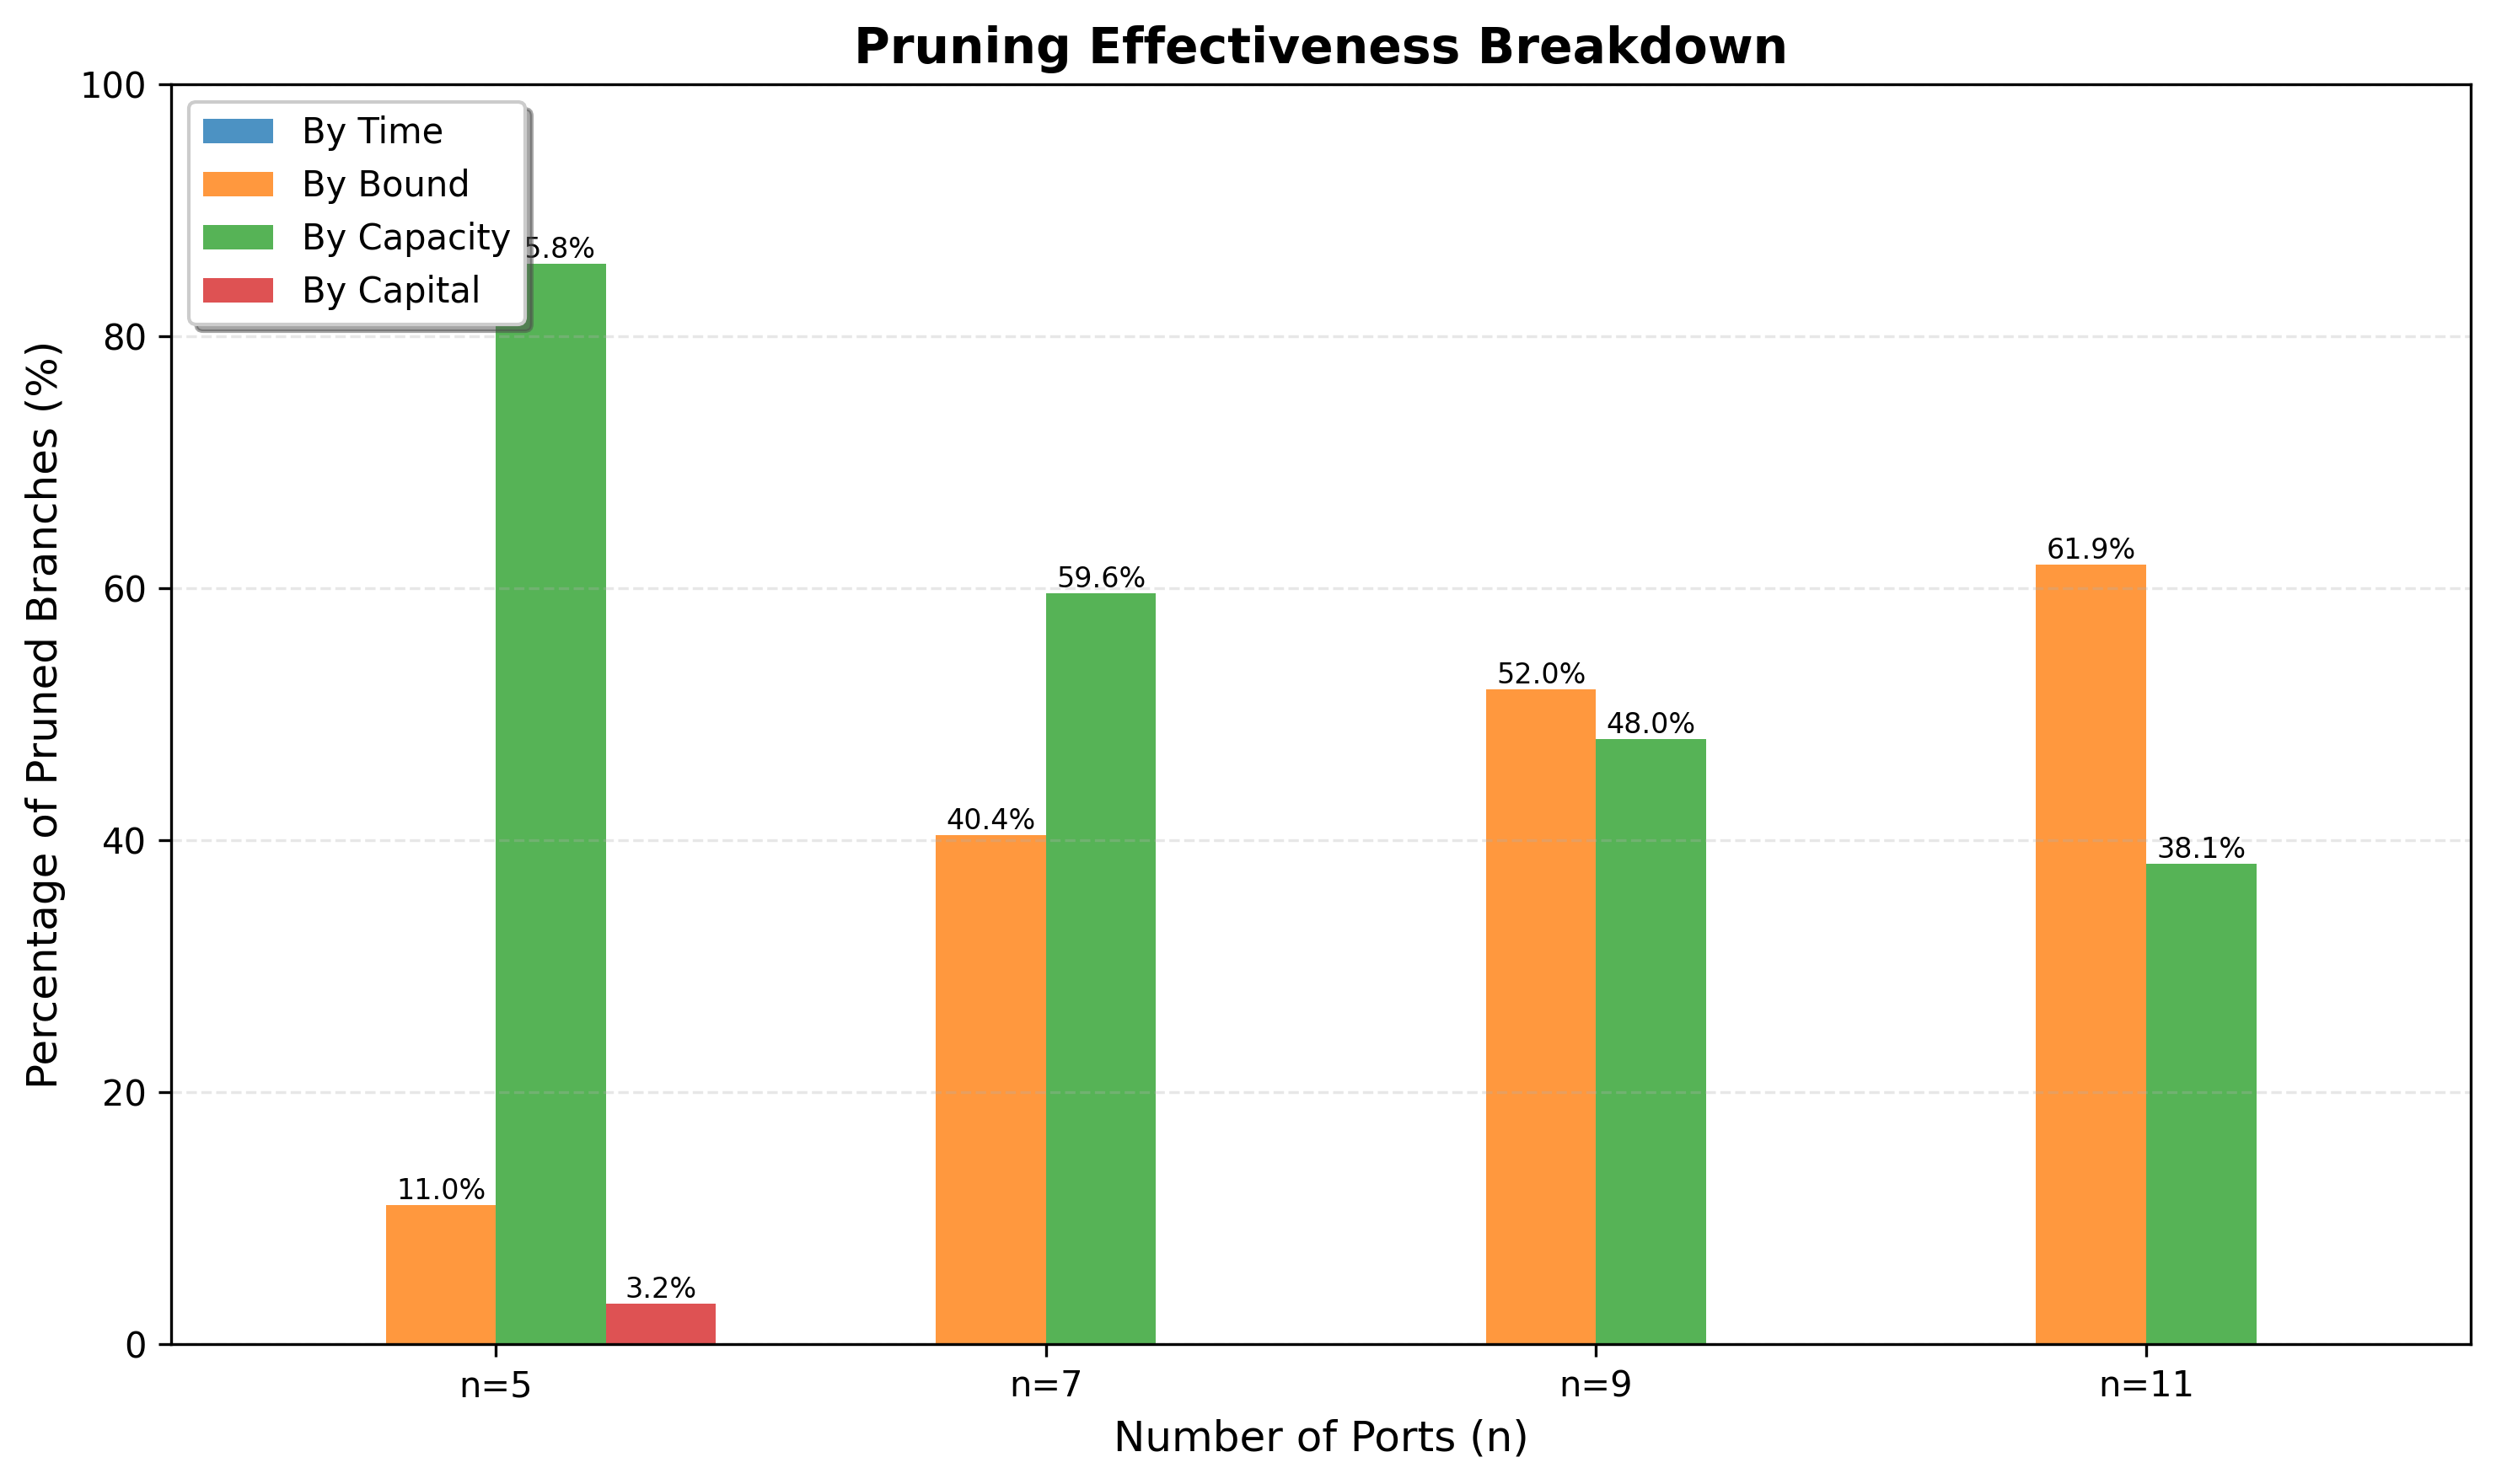

In [29]:
# Generate Figure 3: Pruning Breakdown Visualization (Bar Chart)
def plot_pruning_breakdown(data):
    """Generate bar chart showing pruning breakdown percentages."""
    
    if not data:
        print("No pruning data available")
        return
    
    n_values = [d['n'] for d in data]
    time_pct = [d['pct_time'] for d in data]
    bound_pct = [d['pct_bound'] for d in data]
    capacity_pct = [d['pct_capacity'] for d in data]
    capital_pct = [d['pct_capital'] for d in data]
    
    x = np.arange(len(n_values))
    width = 0.2  # Width for each bar group
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bars (side by side, like the second figure)
    bars1 = ax.bar(x - 1.5*width, time_pct, width, label='By Time', color='#1f77b4', alpha=0.8)
    bars2 = ax.bar(x - 0.5*width, bound_pct, width, label='By Bound', color='#ff7f0e', alpha=0.8)
    bars3 = ax.bar(x + 0.5*width, capacity_pct, width, label='By Capacity', color='#2ca02c', alpha=0.8)
    bars4 = ax.bar(x + 1.5*width, capital_pct, width, label='By Capital', color='#d62728', alpha=0.8)
    
    # Labels
    ax.set_xlabel('Number of Ports (n)', fontsize=12)
    ax.set_ylabel('Percentage of Pruned Branches (%)', fontsize=12)
    ax.set_title('Pruning Effectiveness Breakdown', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in n_values])
    ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim(0, 100)
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            if height is not None and not np.isnan(height) and height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%',
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    
    # Save
    plt.savefig('figures/pruning_breakdown.png', dpi=300, bbox_inches='tight')
    plt.savefig('figures/pruning_breakdown.pdf', bbox_inches='tight')
    print("✓ Figure 3 saved: figures/pruning_breakdown.png and .pdf")
    
    plt.show()

if pruning_data:
    plot_pruning_breakdown(pruning_data)


## Cell 5: Scalability Limit Analysis

Determines the maximum instance size that can be solved within different time budgets (1s, 10s, 60s, 300s).


In [31]:
# Cell 5: Scalability Limit Analysis
def find_scalability_limits():
    """Find maximum solvable n for different time budgets."""
    
    time_budgets = [1.0, 10.0, 60.0, 300.0]  # seconds
    max_n_results = {'time_budget': [], 'max_n': []}
    
    print("="*80)
    print("SCALABILITY LIMIT ANALYSIS (Hybrid Algorithm)")
    print("="*80)
    print(f"\n{'Time Budget (s)':>18} | {'Max n':>8} | {'Actual Time (s)':>18} | {'Status':>15}")
    print("-"*80)
    
    for budget in time_budgets:
        max_n = 3
        last_successful_n = 3
        last_time = 0
        
        # Try increasing n until we exceed the time budget
        for n in range(3, 15):  # Test up to n=14
            try:
                instance = generate_unified_test_instance(n_ports=n, seed=RANDOM_SEED)
                
                start = time.time()
                result = hybrid_brute_force_dp(instance, timeout=budget)
                elapsed = time.time() - start
                
                if elapsed <= budget:
                    max_n = n
                    last_successful_n = n
                    last_time = elapsed
                else:
                    break  # Exceeded budget, stop
                    
            except Exception as e:
                # If it fails or times out, we've exceeded the limit
                break
        
        max_n_results['time_budget'].append(budget)
        max_n_results['max_n'].append(last_successful_n)
        
        status = "Success" if last_successful_n >= 3 else "Failed"
        print(f"{budget:18} | {last_successful_n:8} | {last_time:18.3f} | {status:15}")
    
    return max_n_results

scalability_limits = find_scalability_limits()

# Save to CSV
df_scalability = pd.DataFrame(scalability_limits)
df_scalability.to_csv('data/scalability_limits.csv', index=False)
print("\n✓ Scalability limits data saved to data/scalability_limits.csv")


SCALABILITY LIMIT ANALYSIS (Hybrid Algorithm)

   Time Budget (s) |    Max n |    Actual Time (s) |          Status
--------------------------------------------------------------------------------
               1.0 |        8 |              0.761 | Success        
              10.0 |       10 |              4.704 | Success        
              60.0 |       11 |             30.631 | Success        
             300.0 |       11 |             28.177 | Success        

✓ Scalability limits data saved to data/scalability_limits.csv


✓ Figure 4 saved: figures/scalability_limits.png and .pdf


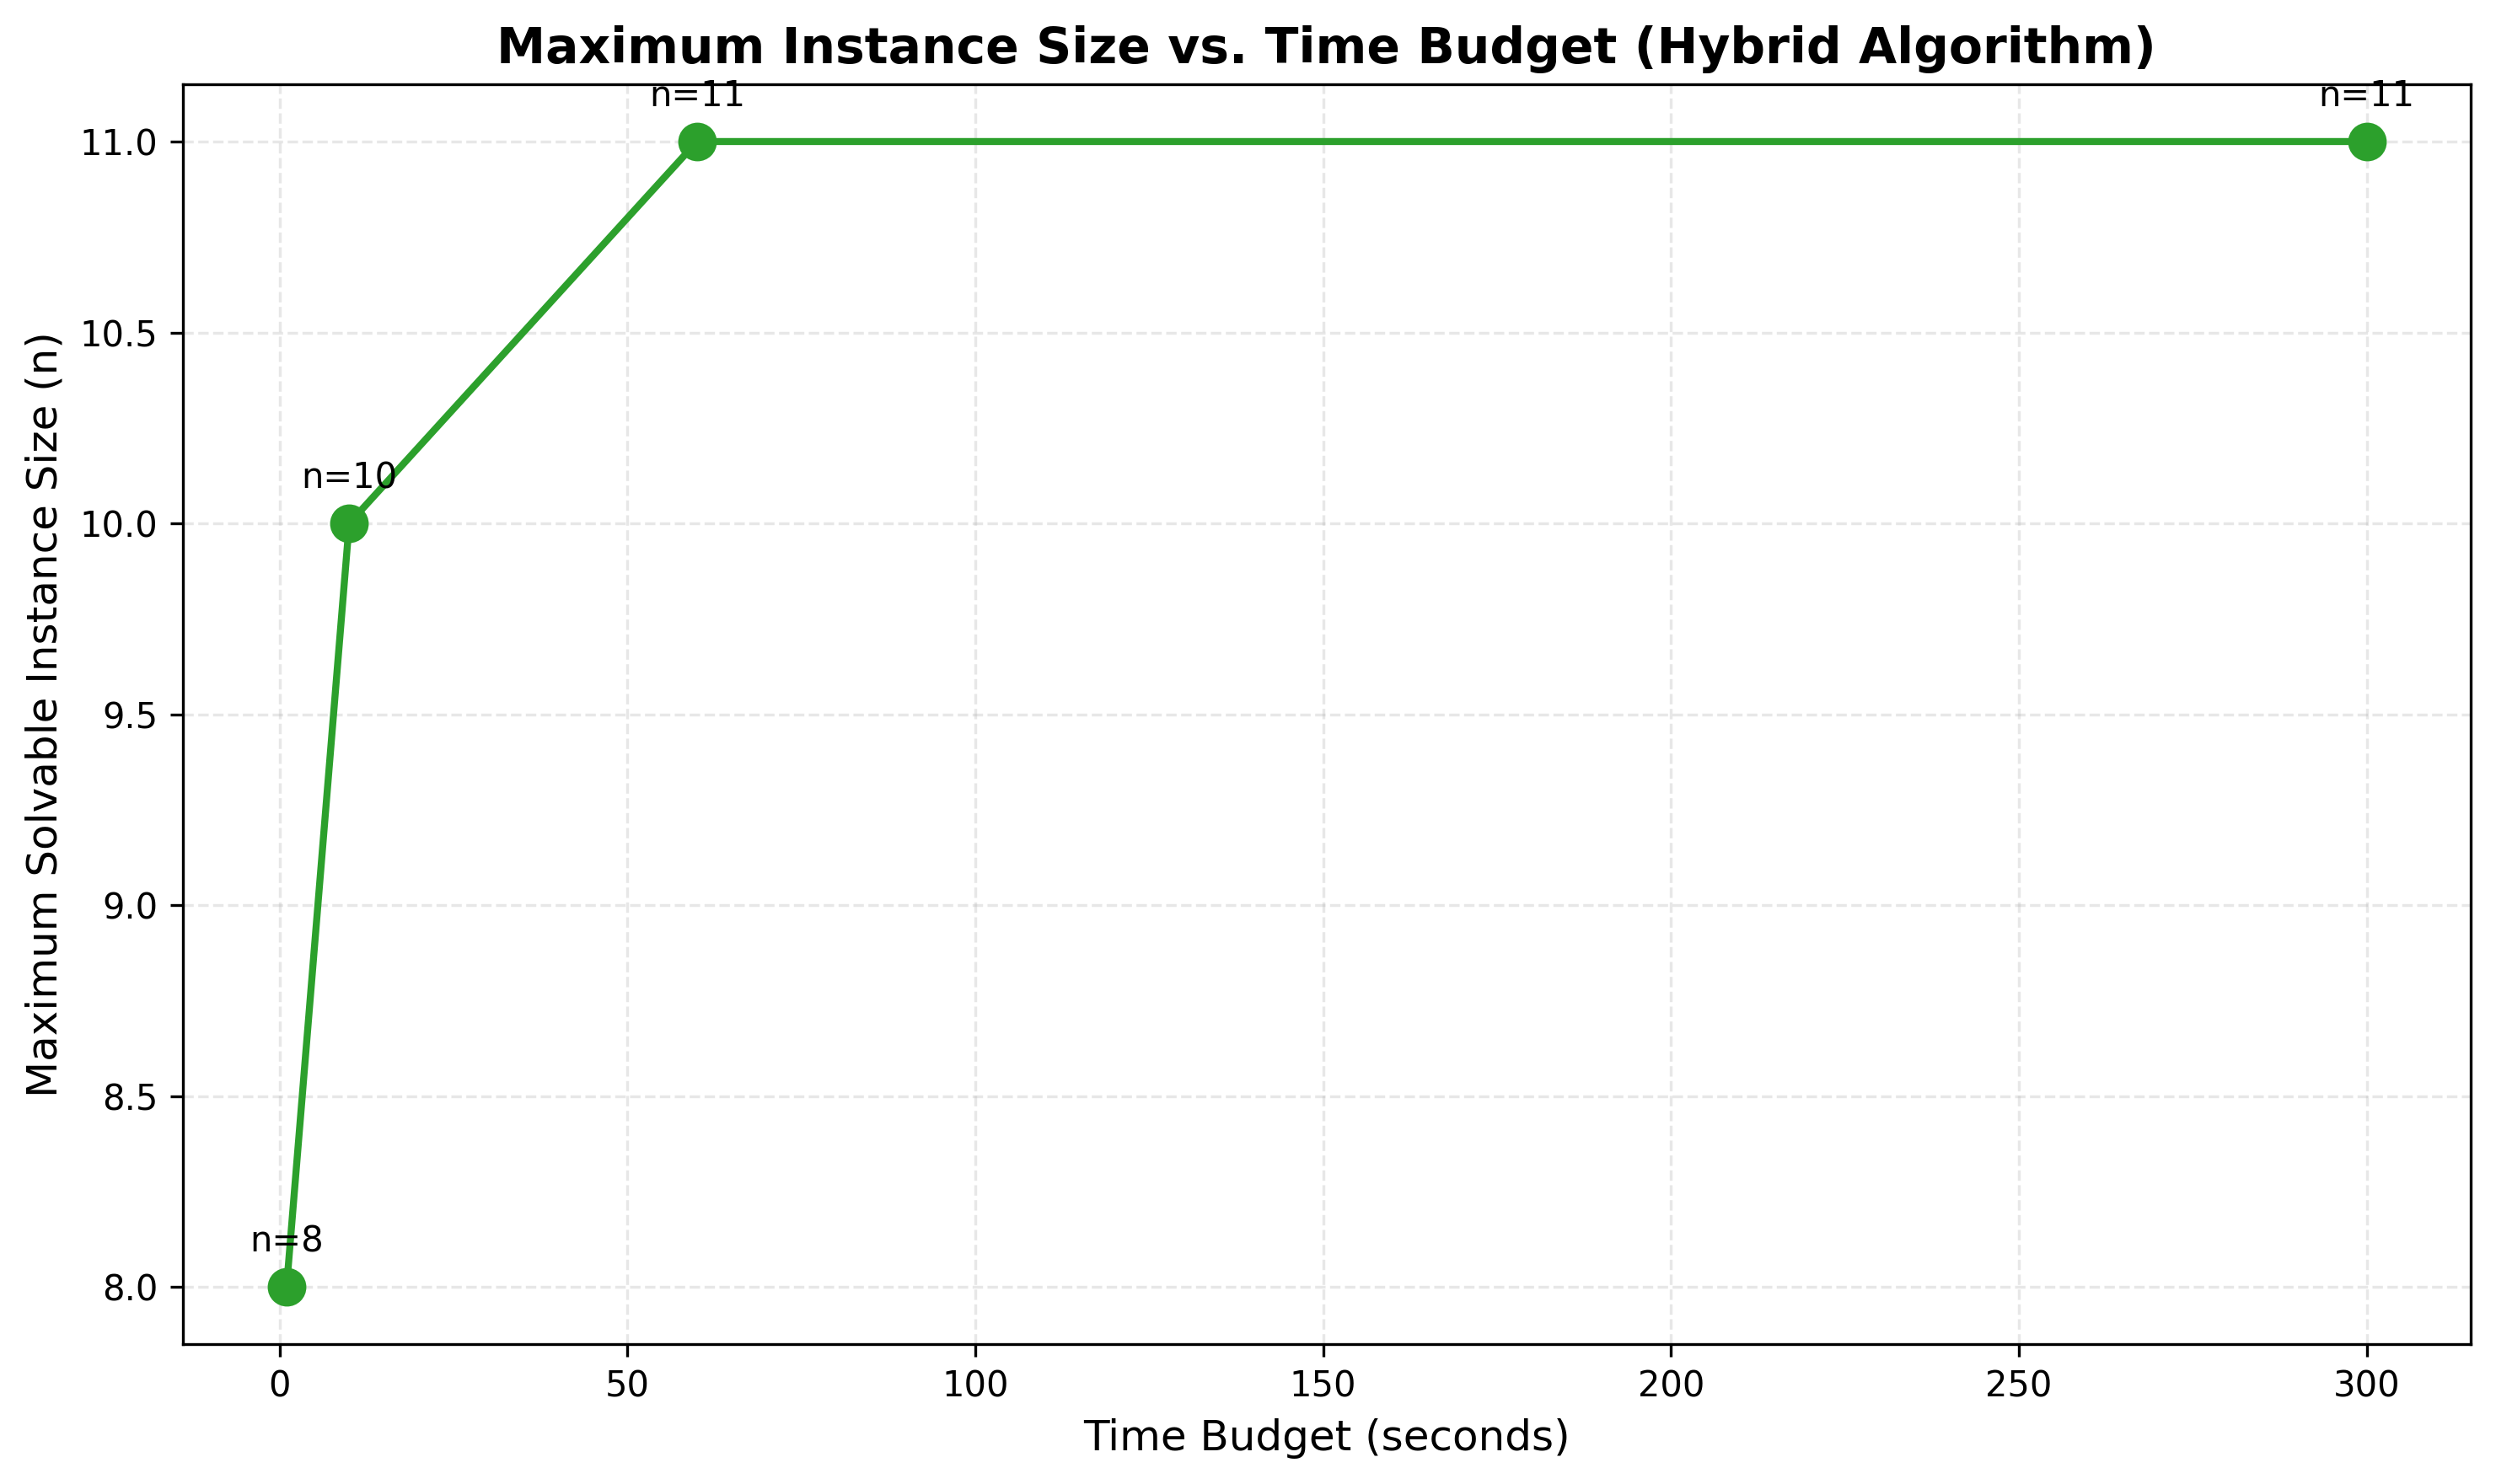

In [32]:
# Generate Figure 4: Scalability Limits
def plot_scalability_limits(results):
    """Generate plot showing maximum solvable n vs time budget."""
    
    budgets = results['time_budget']
    max_n_values = results['max_n']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(budgets, max_n_values, 'o-', linewidth=2, markersize=10, color='#2ca02c')
    
    # Labels
    ax.set_xlabel('Time Budget (seconds)', fontsize=12)
    ax.set_ylabel('Maximum Solvable Instance Size (n)', fontsize=12)
    ax.set_title('Maximum Instance Size vs. Time Budget (Hybrid Algorithm)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add value labels
    for i, (budget, n) in enumerate(zip(budgets, max_n_values)):
        ax.annotate(f'n={n}', (budget, n), textcoords="offset points", 
                   xytext=(0,10), ha='center', fontsize=10)
    
    plt.tight_layout()
    
    # Save
    plt.savefig('figures/scalability_limits.png', dpi=300, bbox_inches='tight')
    plt.savefig('figures/scalability_limits.pdf', bbox_inches='tight')
    print("✓ Figure 4 saved: figures/scalability_limits.png and .pdf")
    
    plt.show()

plot_scalability_limits(scalability_limits)


## Cell 6: Solution Quality Verification

Verifies that all three algorithms find the same optimal solutions when they complete execution on the same instances.


In [33]:
# Cell 6: Solution Quality Verification
def verify_solution_quality():
    """Verify all algorithms find same optimal solutions."""
    
    verification_sizes = [3, 4, 5]  # Sizes where all algorithms can run
    verification_results = []
    
    print("="*80)
    print("SOLUTION QUALITY VERIFICATION")
    print("="*80)
    print(f"\n{'n':>3} | {'Pure BF Capital':>18} | {'Pruned BF Capital':>20} | {'Hybrid Capital':>18} | {'Match':>8}")
    print("-"*80)
    
    for n in verification_sizes:
        # Generate instance with fixed seed
        instance = generate_unified_test_instance(n_ports=n, seed=RANDOM_SEED)
        
        result_entry = {'n': n}
        
        # Run all three algorithms
        try:
            result_pure = pure_brute_force(instance, timeout=200.0)
            capital_pure = result_pure.get('final_capital')
            result_entry['pure_capital'] = capital_pure
        except:
            result_entry['pure_capital'] = None
        
        try:
            result_pruned = brute_force_with_pruning(instance, timeout=200.0)
            capital_pruned = result_pruned.get('final_capital')
            result_entry['pruned_capital'] = capital_pruned
        except:
            result_entry['pruned_capital'] = None
        
        try:
            result_hybrid = hybrid_brute_force_dp(instance, timeout=200.0)
            capital_hybrid = result_hybrid.get('final_capital')
            result_entry['hybrid_capital'] = capital_hybrid
        except:
            result_entry['hybrid_capital'] = None
        
        # Check if all match
        capitals = [result_entry['pure_capital'], result_entry['pruned_capital'], result_entry['hybrid_capital']]
        valid_capitals = [c for c in capitals if c is not None]
        
        if len(valid_capitals) >= 2:
            match = all(abs(c - valid_capitals[0]) < 0.01 for c in valid_capitals)
            result_entry['match'] = match
            match_str = "✓ Match" if match else "✗ Mismatch"
        else:
            result_entry['match'] = None
            match_str = "N/A"
        
        # Print
        pure_str = f"{result_entry['pure_capital']:.2f}" if result_entry['pure_capital'] else "N/A"
        pruned_str = f"{result_entry['pruned_capital']:.2f}" if result_entry['pruned_capital'] else "N/A"
        hybrid_str = f"{result_entry['hybrid_capital']:.2f}" if result_entry['hybrid_capital'] else "N/A"
        
        print(f"{n:3} | {pure_str:>18} | {pruned_str:>20} | {hybrid_str:>18} | {match_str:>8}")
        
        verification_results.append(result_entry)
    
    # Summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY")
    print("="*80)
    matches = [r['match'] for r in verification_results if r['match'] is not None]
    if matches:
        all_match = all(matches)
        print(f"All algorithms find identical optimal solutions: {'✓ YES' if all_match else '✗ NO'}")
        if all_match:
            print("✓ Confirmed: All three algorithms are exact methods (guarantee optimality)")
    else:
        print("Could not verify (not all algorithms completed)")
    
    return verification_results

quality_verification = verify_solution_quality()

# Save to CSV
df_quality = pd.DataFrame(quality_verification)
df_quality.to_csv('data/quality_verification.csv', index=False)
print("\n✓ Quality verification data saved to data/quality_verification.csv")


SOLUTION QUALITY VERIFICATION

  n |    Pure BF Capital |    Pruned BF Capital |     Hybrid Capital |    Match
--------------------------------------------------------------------------------
  3 |              78.00 |                78.00 |              78.00 |  ✓ Match
  4 |              89.00 |                89.00 |              89.00 |  ✓ Match
  5 |             116.00 |               116.00 |             116.00 |  ✓ Match

VERIFICATION SUMMARY
All algorithms find identical optimal solutions: ✓ YES
✓ Confirmed: All three algorithms are exact methods (guarantee optimality)

✓ Quality verification data saved to data/quality_verification.csv


In [34]:
# Cell 7: Instance Characteristics Analysis
def generate_instance_with_characteristics(n, profit_margin='high', time_constraint='loose', capacity='normal'):
    """Generate instance with specific characteristics."""
    import random
    random.seed(RANDOM_SEED)
    
    ports = ['Amsterdam'] + [f'Port_{i}' for i in range(1, n)]
    
    # Cost and time matrices
    costs = [[0] * n for _ in range(n)]
    travel_times = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(i + 1, n):
            if time_constraint == 'tight':
                cost = random.randint(5, 12)
                time_val = random.randint(4, 8)
            else:  # loose
                cost = random.randint(2, 8)
                time_val = random.randint(1, 5)
            
            costs[i][j] = cost
            costs[j][i] = cost
            travel_times[i][j] = time_val
            travel_times[j][i] = time_val
    
    # Prices based on profit margin
    if profit_margin == 'high':
        purchase_prices = [0] + [random.randint(8, 15) for _ in range(n - 1)]
        sale_prices = [0] + [p + random.randint(20, 30) for p in purchase_prices[1:]]
    else:  # low
        purchase_prices = [0] + [random.randint(10, 20) for _ in range(n - 1)]
        sale_prices = [0] + [p + random.randint(5, 10) for p in purchase_prices[1:]]
    
    # Capacity
    if capacity == 'high':
        B = min(5, n - 1)
    else:  # normal
        B = min(3, n - 1)
    
    # Time limit
    if time_constraint == 'tight':
        max_time = 10 + (n - 2) * 3
    else:  # loose
        max_time = 20 + (n - 2) * 10
    
    initial_capital = 100 if profit_margin == 'high' else 150
    
    return {
        'ports': ports,
        'travel_costs': costs,
        'travel_times': travel_times,
        'purchase_prices': purchase_prices,
        'sale_prices': sale_prices,
        'initial_capital': initial_capital,
        'capacity': B,
        'max_time': max_time
    }

def run_characteristics_analysis():
    """Analyze performance under different instance characteristics."""
    
    n = 5  # Fixed size for comparison
    characteristics = []
    
    print("="*80)
    print("INSTANCE CHARACTERISTICS ANALYSIS")
    print("="*80)
    print(f"\n{'Characteristic':>25} | {'Pure BF (s)':>15} | {'Pruned BF (s)':>15} | {'Hybrid (s)':>15}")
    print("-"*80)
    
    configs = [
        ('high', 'loose', 'normal', 'High Profit, Loose Time'),
        ('high', 'tight', 'normal', 'High Profit, Tight Time'),
        ('low', 'loose', 'normal', 'Low Profit, Loose Time'),
        ('low', 'tight', 'normal', 'Low Profit, Tight Time'),
        ('high', 'loose', 'high', 'High Profit, High Capacity'),
    ]
    
    for profit, time_c, cap, desc in configs:
        instance = generate_instance_with_characteristics(n, profit, time_c, cap)
        
        entry = {
            'characteristic': desc,
            'profit_margin': profit,
            'time_constraint': time_c,
            'capacity': cap
        }
        
        # Test Pure BF
        try:
            start = time.time()
            result = pure_brute_force(instance, timeout=200.0)
            time_pure = time.time() - start
            entry['pure_time'] = time_pure
        except:
            entry['pure_time'] = float('inf')
        
        # Test Pruned BF
        try:
            start = time.time()
            result = brute_force_with_pruning(instance, timeout=200.0)
            time_pruned = time.time() - start
            entry['pruned_time'] = time_pruned
        except:
            entry['pruned_time'] = float('inf')
        
        # Test Hybrid
        try:
            start = time.time()
            result = hybrid_brute_force_dp(instance, timeout=200.0)
            time_hybrid = time.time() - start
            entry['hybrid_time'] = time_hybrid
        except:
            entry['hybrid_time'] = float('inf')
        
        characteristics.append(entry)
        
        pure_str = f"{entry['pure_time']:.4f}" if entry['pure_time'] != float('inf') else "N/A"
        pruned_str = f"{entry['pruned_time']:.4f}" if entry['pruned_time'] != float('inf') else "N/A"
        hybrid_str = f"{entry['hybrid_time']:.4f}" if entry['hybrid_time'] != float('inf') else "N/A"
        
        print(f"{desc:>25} | {pure_str:>15} | {pruned_str:>15} | {hybrid_str:>15}")
    
    return characteristics

characteristics_results = run_characteristics_analysis()

# Save to CSV
df_char = pd.DataFrame(characteristics_results)
df_char.to_csv('data/characteristics_analysis.csv', index=False)
print("\n✓ Characteristics analysis data saved to data/characteristics_analysis.csv")


INSTANCE CHARACTERISTICS ANALYSIS

           Characteristic |     Pure BF (s) |   Pruned BF (s) |      Hybrid (s)
--------------------------------------------------------------------------------
  High Profit, Loose Time |          0.0043 |          0.0032 |          0.0018
  High Profit, Tight Time |          0.0033 |          0.0021 |          0.0003
   Low Profit, Loose Time |          0.0040 |          0.0011 |          0.0008
   Low Profit, Tight Time |          0.0039 |          0.0021 |          0.0002
High Profit, High Capacity |          0.0061 |          0.0088 |          0.0047

✓ Characteristics analysis data saved to data/characteristics_analysis.csv


In [35]:
# Cell 8: Data Export for Report
def export_all_data():
    """Export all data in formats suitable for LaTeX report."""
    
    print("="*80)
    print("DATA EXPORT FOR REPORT")
    print("="*80)
    
    # 1. Export execution time comparison table (LaTeX format)
    print("\n1. Execution Time Comparison Table (LaTeX):")
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Execution Time Comparison (seconds)}")
    print("\\label{tab:execution_times}")
    print("\\begin{tabular}{c|ccc|cc}")
    print("\\toprule")
    print("$n$ & Pure BF & Pruned BF & Hybrid & Speedup (Pruned) & Speedup (Hybrid) \\\\")
    print("\\midrule")
    
    for i, n in enumerate(growth_results['n']):
        pure_t = growth_results['pure_bf_time'][i]
        pruned_t = growth_results['pruned_bf_time'][i]
        hybrid_t = growth_results['hybrid_time'][i]
        
        pure_str = f"{pure_t:.4f}" if pure_t != float('inf') else "N/A"
        pruned_str = f"{pruned_t:.4f}" if pruned_t != float('inf') else "N/A"
        hybrid_str = f"{hybrid_t:.4f}" if hybrid_t != float('inf') else "N/A"
        
        speedup_pruned = f"{pure_t/pruned_t:.1f}$\\times$" if pure_t != float('inf') and pruned_t != float('inf') else "N/A"
        speedup_hybrid = f"{pure_t/hybrid_t:.1f}$\\times$" if pure_t != float('inf') and hybrid_t != float('inf') else "N/A"
        
        print(f"{n} & {pure_str} & {pruned_str} & {hybrid_str} & {speedup_pruned} & {speedup_hybrid} \\\\")
    
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    
    # 2. Export all data to JSON for easy access
    all_data = {
        'growth_analysis': growth_results,
        'comparison_test': comparison_results,
        'pruning_analysis': pruning_data,
        'scalability_limits': scalability_limits,
        'quality_verification': quality_verification,
        'characteristics_analysis': characteristics_results
    }
    
    # Convert to JSON-serializable format
    json_data = {}
    for key, value in all_data.items():
        if isinstance(value, list):
            json_data[key] = value
        elif isinstance(value, dict):
            # Handle dicts with potentially non-serializable values
            json_data[key] = {k: (v if v != float('inf') else 'inf') for k, v in value.items()}
    
    with open('data/all_experimental_data.json', 'w') as f:
        json.dump(json_data, f, indent=2, default=str)
    
    print("\n✓ All data exported to data/all_experimental_data.json")
    
    # 3. Create summary report
    print("\n2. Summary Report:")
    print("-"*80)
    print(f"Total experiments completed: {len(growth_results['n'])} instance sizes")
    print(f"Figures generated: 4 (growth_curves, comparison_bar_chart, pruning_breakdown, scalability_limits)")
    print(f"Data files created: 6 CSV files + 1 JSON file")
    print(f"All outputs saved to 'figures/' and 'data/' directories")
    
    # 4. List all generated files
    print("\n3. Generated Files:")
    print("-"*80)
    print("Figures:")
    print("  - figures/growth_curves.png/.pdf")
    print("  - figures/comparison_bar_chart.png/.pdf")
    print("  - figures/pruning_breakdown.png/.pdf")
    print("  - figures/scalability_limits.png/.pdf")
    print("\nData:")
    print("  - data/growth_analysis.csv")
    print("  - data/comparison_test.csv")
    print("  - data/pruning_analysis.csv")
    print("  - data/scalability_limits.csv")
    print("  - data/quality_verification.csv")
    print("  - data/characteristics_analysis.csv")
    print("  - data/all_experimental_data.json")
    
    print("\n" + "="*80)
    print("✓ All data export complete!")
    print("="*80)

export_all_data()


DATA EXPORT FOR REPORT

1. Execution Time Comparison Table (LaTeX):
\begin{table}[h]
\centering
\caption{Execution Time Comparison (seconds)}
\label{tab:execution_times}
\begin{tabular}{c|ccc|cc}
\toprule
$n$ & Pure BF & Pruned BF & Hybrid & Speedup (Pruned) & Speedup (Hybrid) \\
\midrule
3 & 0.0003 & 0.0001 & 0.0003 & 2.1$\times$ & 1.3$\times$ \\
4 & 0.0004 & 0.0004 & 0.0004 & 1.1$\times$ & 1.0$\times$ \\
5 & 0.0067 & 0.0021 & 0.0017 & 3.1$\times$ & 3.8$\times$ \\
6 & 0.1018 & 0.0308 & 0.0312 & 3.3$\times$ & 3.3$\times$ \\
7 & 1.0368 & 0.2730 & 0.1856 & 3.8$\times$ & 5.6$\times$ \\
8 & 21.2869 & 5.0484 & 0.3884 & 4.2$\times$ & 54.8$\times$ \\
9 & 200.0011 & 90.7548 & 9.7152 & 2.2$\times$ & 20.6$\times$ \\
10 & N/A & 200.0005 & 5.1573 & N/A & N/A \\
11 & N/A & N/A & 31.9570 & N/A & N/A \\
12 & N/A & N/A & 200.0000 & N/A & N/A \\
\bottomrule
\end{tabular}
\end{table}

✓ All data exported to data/all_experimental_data.json

2. Summary Report:
---------------------------------------------